In [1]:
import pandas as pd
from matplotlib import pyplot as plt

from trainer.src.influx_reader import load_data

# EDA

In [2]:
df = load_data()

In [3]:
df.shape

(11444, 11)

In [4]:
df.head()

,time,device_id,current,failure,humidity,load,pressure,rpm,temperature,vibration,wear
0,2026-08-13T08:54:27.354064+00:00,motor_000,15.35,0,44.0,0.558,6.02,2143.0,59.94,0.63,0.0001
1,2026-08-13T08:54:28.644359+00:00,motor_000,15.55,0,49.7,0.539,6.09,2151.0,58.60,0.52,0.0003
2,2026-08-13T08:54:29.659000+00:00,motor_000,14.02,0,45.0,0.540,5.98,2170.0,58.83,0.58,0.0004
3,2026-08-13T08:54:30.673773+00:00,motor_000,14.93,0,46.0,0.541,5.91,2178.0,58.44,0.51,0.0005
4,2026-08-13T08:54:31.678822+00:00,motor_000,14.79,0,39.9,0.542,6.04,2154.0,59.65,0.61,0.0007


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11444 entries, 0 to 11443
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   time         11444 non-null  str    
 1   device_id    11444 non-null  str    
 2   current      11444 non-null  float64
 3   failure      11444 non-null  int64  
 4   humidity     11444 non-null  float64
 5   load         11444 non-null  float64
 6   pressure     11444 non-null  float64
 7   rpm          11444 non-null  float64
 8   temperature  11444 non-null  float64
 9   vibration    11444 non-null  float64
 10  wear         11444 non-null  float64
dtypes: float64(8), int64(1), str(2)
memory usage: 983.6 KB


In [6]:
df.describe()

,current,failure,humidity,load,pressure,rpm,temperature,vibration,wear
count,11444.000000,11444.000000,11444.000000,11444.000000,11444.000000,11444.000000,11444.000000,11444.000000,11444.000000
mean,17.770778,0.003757,44.996977,0.701229,5.946413,2333.802254,65.372148,0.690652,0.025912
std,4.057984,0.061185,3.951318,0.217051,0.250376,290.451214,8.188753,0.345780,0.020477
min,1.510000,0.000000,26.900000,0.200000,1.580000,171.000000,45.510000,0.260000,0.000100
25%,14.747500,0.000000,42.300000,0.536000,5.920000,2142.000000,59.250000,0.580000,0.009300
50%,18.650000,0.000000,45.100000,0.748000,5.960000,2396.000000,66.815000,0.690000,0.020900
75%,21.112500,0.000000,47.700000,0.883000,6.000000,2558.000000,71.630000,0.770000,0.038200
max,24.480000,1.000000,61.100000,1.000000,6.190000,2754.000000,113.960000,6.930000,0.098800


In [7]:
df["device_id"].nunique()

4

In [8]:
df["device_id"].value_counts()

device_id
motor_000    2916
motor_001    2916
motor_002    2834
motor_003    2778
Name: count, dtype: int64

In [9]:
df.groupby("device_id")["time"].agg(["min", "max", "count"])

,min,max,count
device_id,,,
motor_000,2026-08-13T08:54:27.354064+00:00,2026-08-13T09:43:34.068576+00:00,2916
motor_001,2026-08-13T08:54:27.451405+00:00,2026-08-13T09:43:34.076513+00:00,2916
motor_002,2026-08-13T08:54:27.411811+00:00,2026-08-13T09:43:34.073656+00:00,2834
motor_003,2026-08-13T08:54:27.484919+00:00,2026-08-13T09:43:34.075390+00:00,2778


# Some plots

In [10]:
features = df.columns.drop('time').drop('device_id')
features

Index(['current', 'failure', 'humidity', 'load', 'pressure', 'rpm',
       'temperature', 'vibration', 'wear'],
      dtype='str')

In [11]:
device = "motor_001"

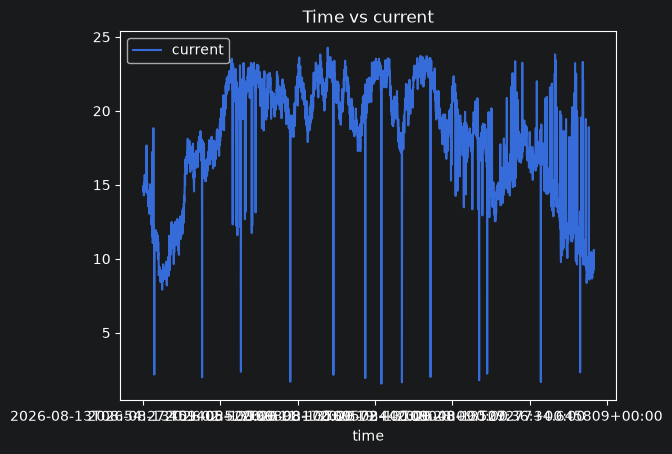

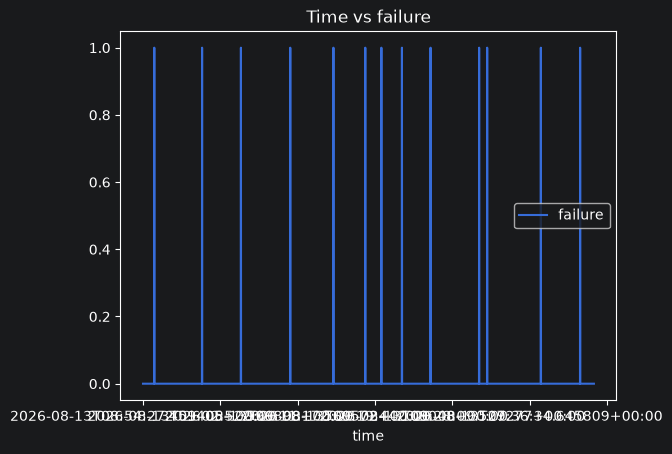

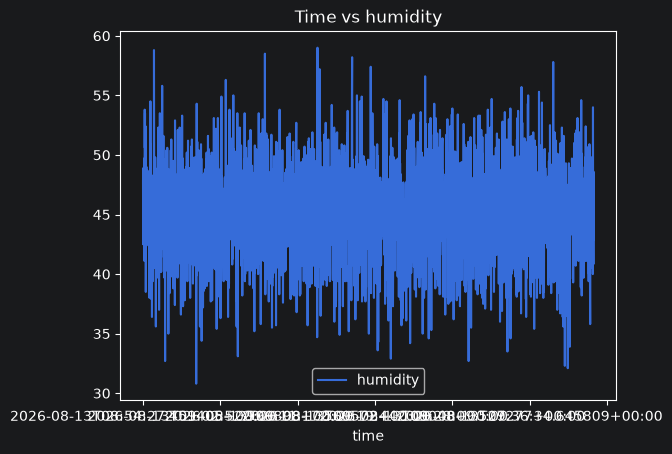

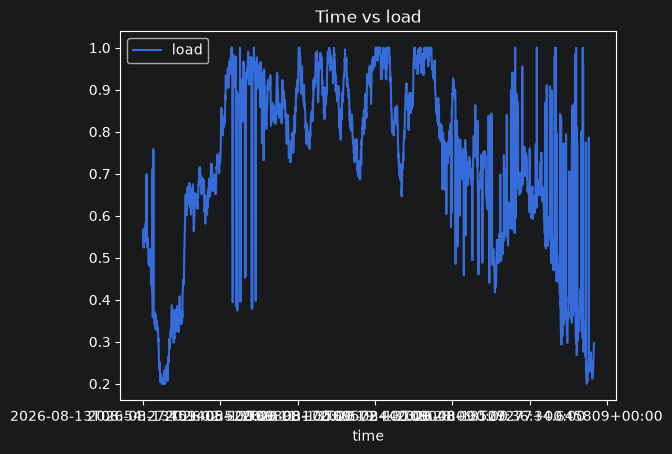

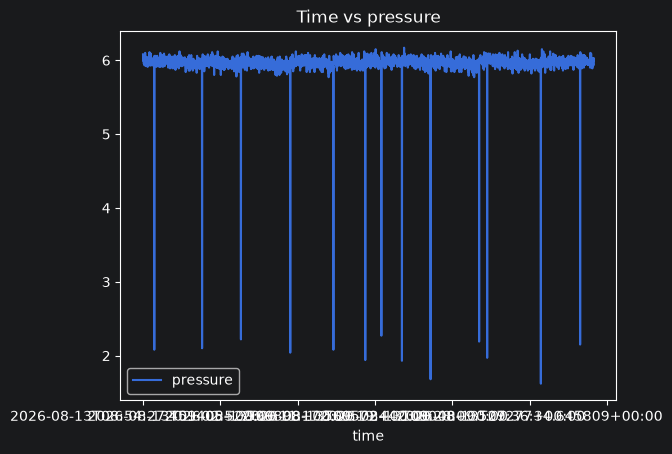

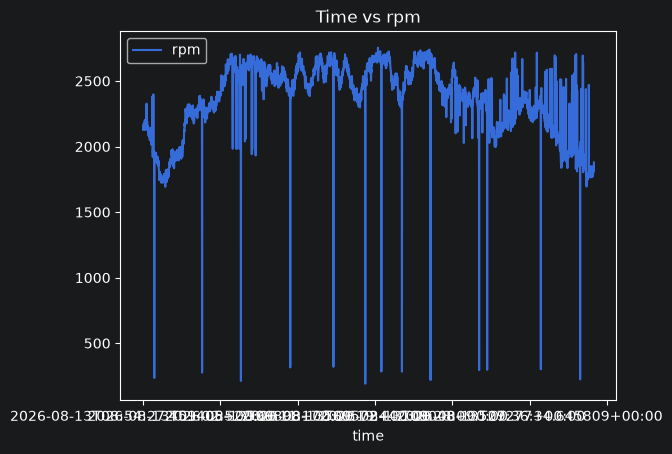

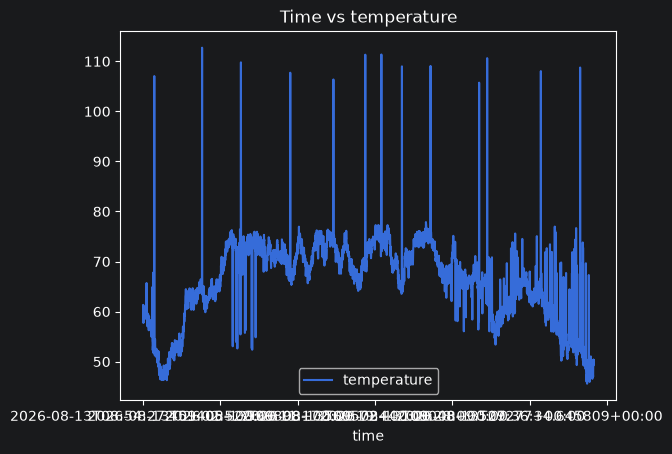

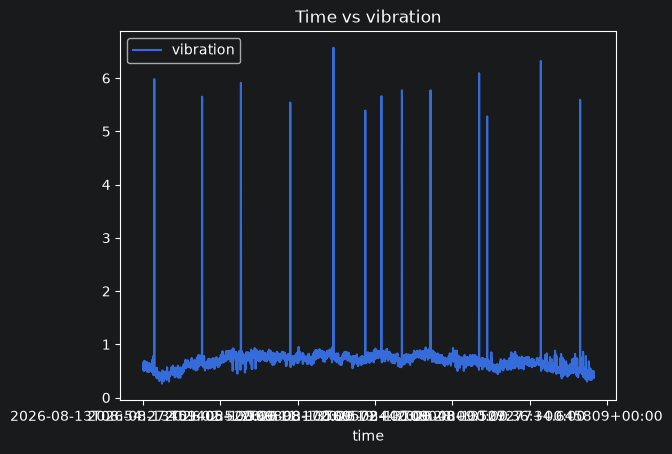

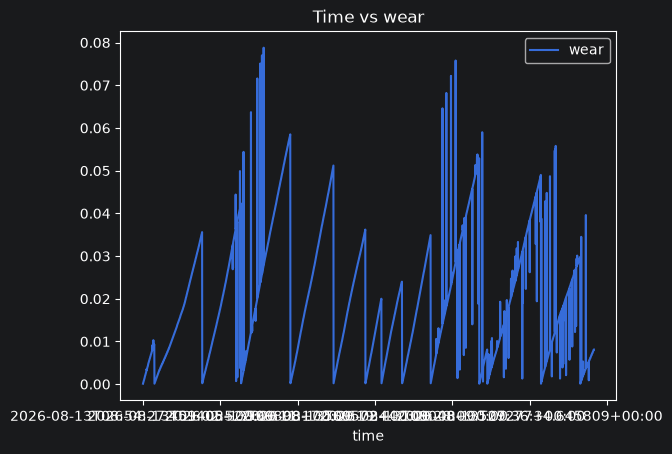

In [12]:
subset = df[df['device_id'] == device].drop(columns='device_id')

for feature in features:
    subset.plot(x='time',
                y=feature,
                title=f"Time vs {feature}")

looks like spikes in some features lead to spikes in failure, lets see

In [13]:
# time as index for faster plots
subset = subset.set_index('time')
subset.index = pd.to_datetime(subset.index)

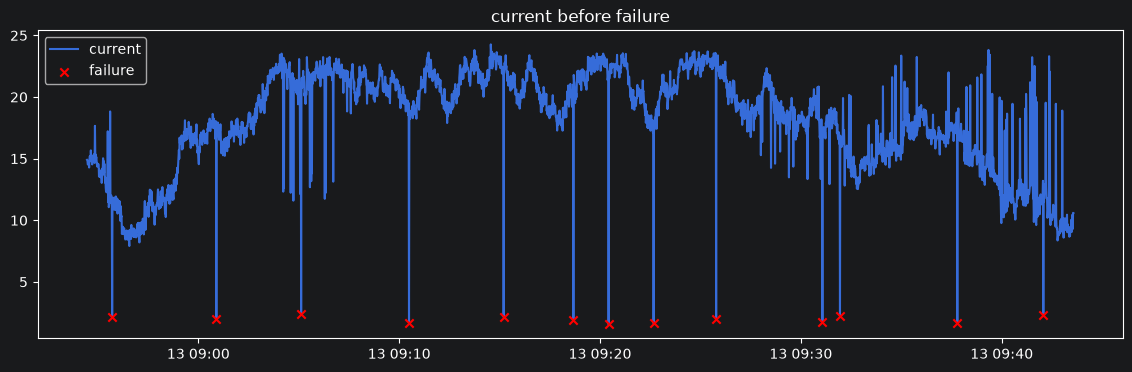

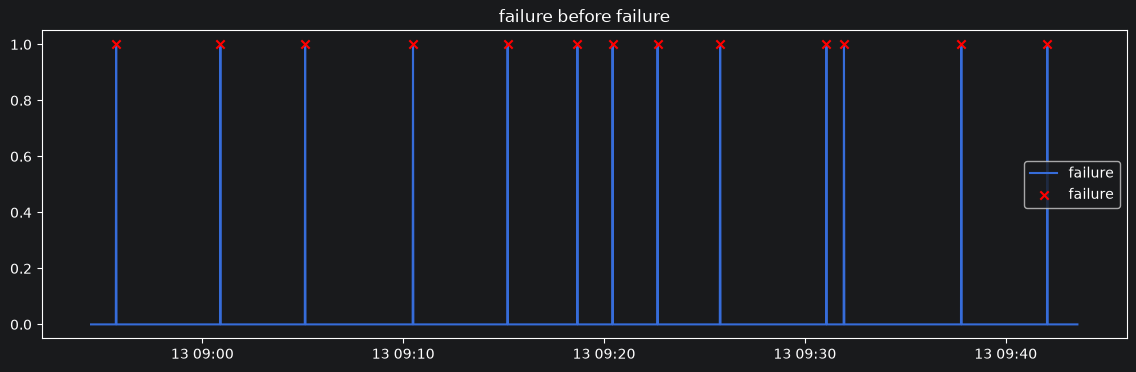

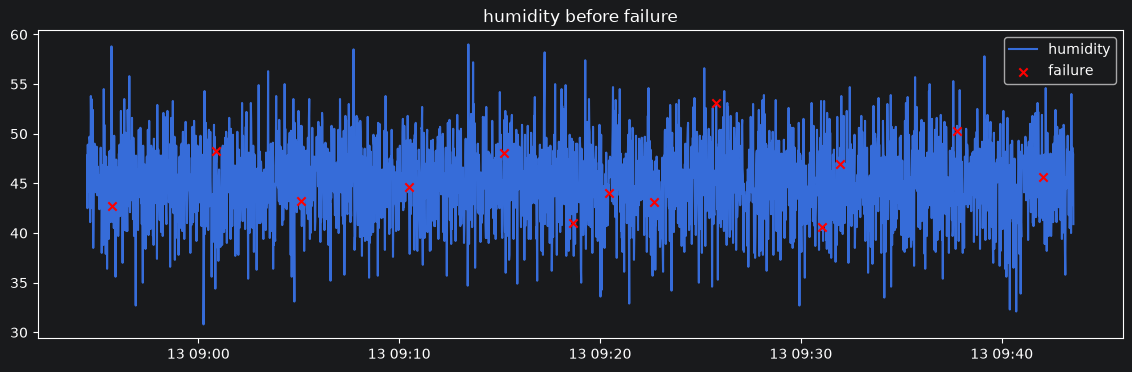

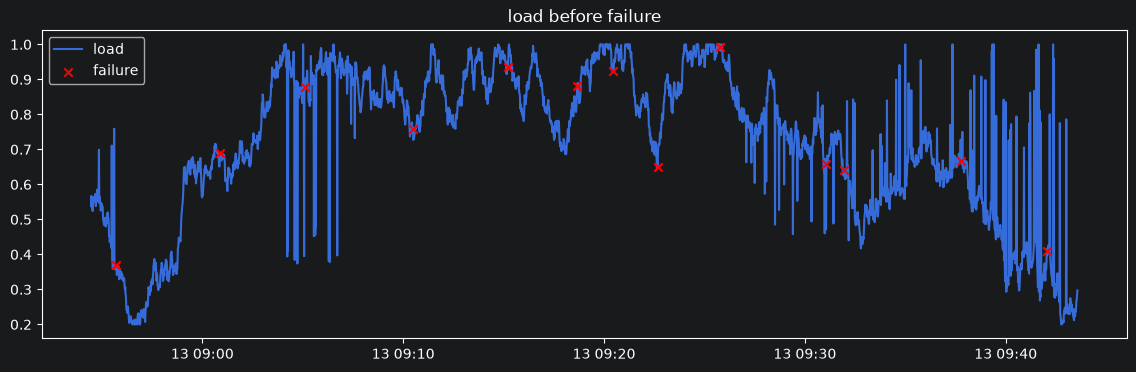

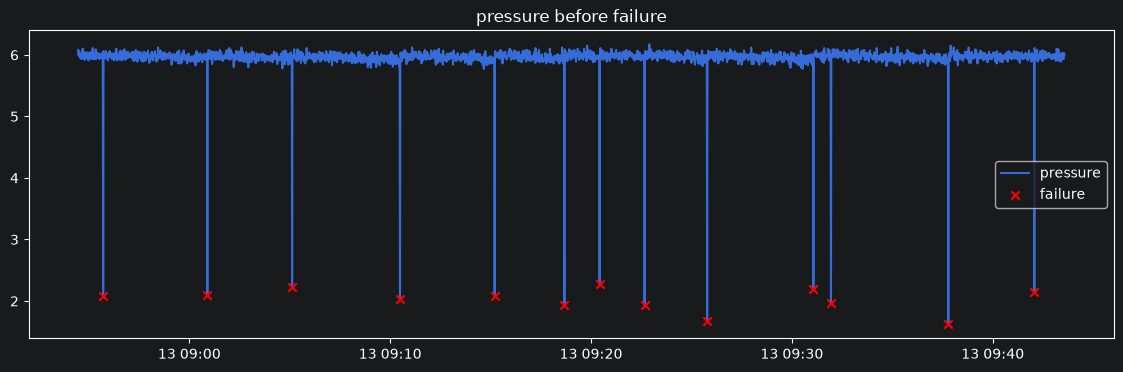

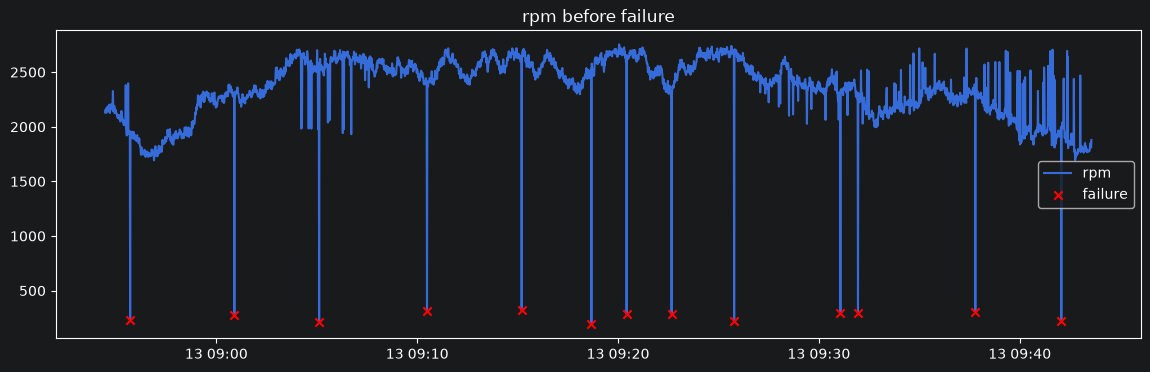

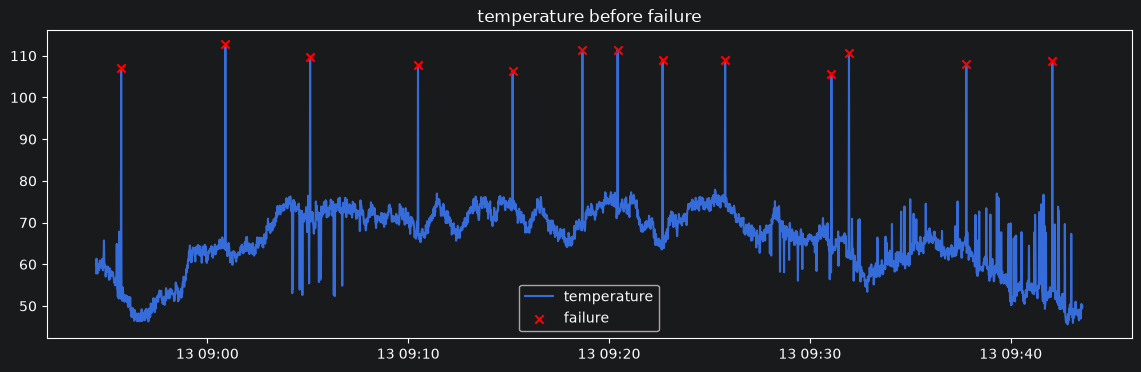

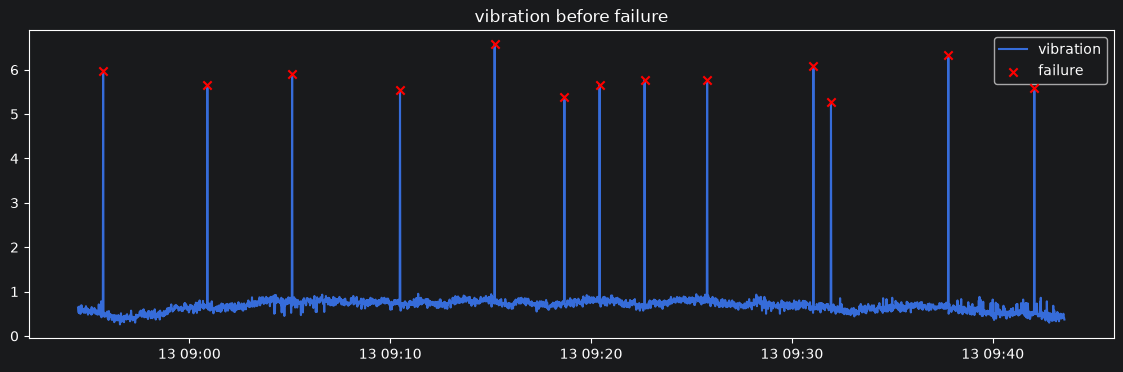

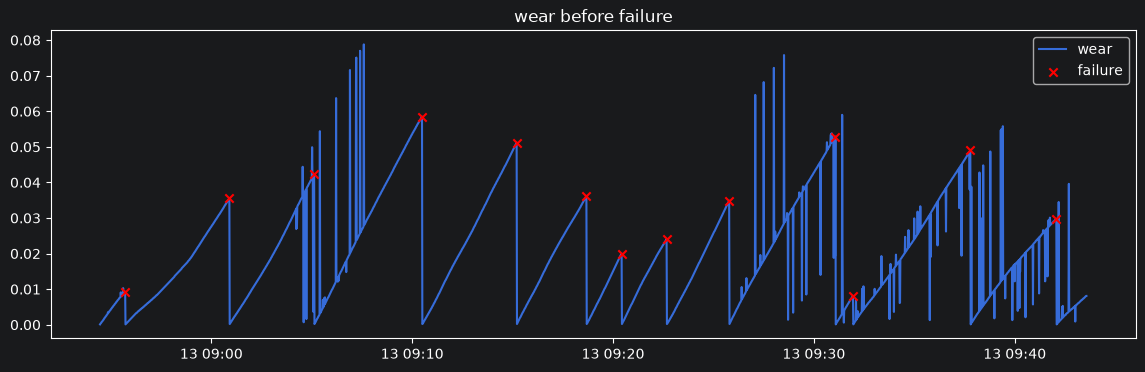

In [14]:
failure_points = subset[subset["failure"] == 1]

for feature in features:
    plt.figure(figsize=(14, 4))

    plt.plot(
        subset.index,
        subset[feature],
        label=feature,
        zorder=1
    )

    plt.scatter(
        failure_points.index,
        failure_points[feature],
        marker='x',
        label='failure',
        color='red',
        zorder=10
    )

    plt.title(f"{feature} before failure")
    plt.legend()
    plt.show()